MINI PROJETO AVALIATIVO

DATAVIEW: EXPLORAÇÃO E ÁNALISE DE DADOS DE VENDAS

In [ ]:
# IMPORTAÇÃO DAS BIBLIOTECAS DO PYTHON UTLIZADAS.

import pandas as pd
import numpy as np
import random
import re
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


RF01 - GERANDO E CARREGANDO O DATASET DE VENDAS


In [ ]:
def gerar_dataset_vendas(n_registros=180, seed=42):
    """Gera um dataset sintético de vendas com dados propositalmente sujos,
    incluindo valores nulos, strings sujas, datas inválidas e outliers."""
    random.seed(seed)
    np.random.seed(seed)

    produtos = ['Notebook', 'Smartphone', 'Tablet', 'Monitor', 'Teclado', 'Mouse','Baterias Notebook', 'Power Bank']
    precos = { 'Notebook': 4299, 'Smartphone': 2899, 'Tablet': 1999, 'Monitor': 1399, 'Teclado': 249, 'Mouse': 109, 'Baterias Notebook': 299, 'Power Bank': 119 }
    categorias = { "Notebook": "Computadores", "Smartphone": "Celulares", "Tablet": "Celulares", "Monitor": "Computadores", "Teclado": "Periféricos", "Mouse": "Periféricos", "Baterias Notebook": "Acessórios", "Power Bank": "Acessórios" }
    regioes = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
    clientes = [f"Cliente_{i:03d}" for i in range(1, 31)]

    data_inicio = datetime(2022, 1, 1)
    dados = []

    for i in range(n_registros):
        produto = random.choice(produtos)
        quantidade = random.randint(1, 10)
        preco = precos[produto]
        mes_pesos = [8, 5, 7, 8, 10, 7, 6, 8, 8, 9, 10, 12]
        mes = random.choices(range(1, 13), weights=mes_pesos)[0]
        dia = random.randint(1, 28)
        data = datetime(2022, mes, dia)

        # Inserindo dados intencionalmente sujos para limpeza
        if random.random() < 0.05:
            quantidade = None          # valor nulo
        if random.random() < 0.04:
            preco = None               # valor nulo
        if random.random() < 0.03:
            produto = "  " + produto   # espaço extra (string suja)

        data_str = data.strftime("%Y-%m-%d") if random.random() > 0.02 else "DATA INVALIDA"

        dados.append({
            "id_venda": i + 1,
            "data_venda": data_str,
            "cliente": random.choice(clientes),
            "produto": produto,
            "categoria": categorias.get(produto.strip(), "Outros"),
            "regiao": random.choices(
            ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"],
            weights=[35, 30, 20, 10, 5])[0],
            "quantidade": quantidade,
            "preco_unitario": preco
        })

    return pd.DataFrame(dados)

# Gerar e salvar
df_total = gerar_dataset_vendas()
os.makedirs('data/raw', exist_ok=True) # Adicionado para garantir que o diretório exista
df_total.to_csv("data/raw/vendas.csv", index=False)
print(f"Dataset gerado com {len(df_total)} registros.")



Dataset gerado com 180 registros.


RF02 - INSPEÇÃO E DESCRIÇÃO DOS DADOS

In [ ]:
#Função que Exibe informações básicas do DataFrame.
def inspecionar_dados(df):
    print("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print(f"Shape: {df.shape}")
    print(f"\nColunas: {list(df.columns)}")
    print(f"\nTipos de dados:\n{df.dtypes}")
    print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df.head()}")
    print(f'\nÚltimos registros:\n{df.tail()}')
    print(f"\nEstatísticas descritivas:\n{df.describe()}")
    return df.describe(include="all")

inspecionar_dados(df_total)



=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (180, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda         object
cliente            object
produto            object
categoria          object
regiao             object
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        8
preco_unitario    9
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente            produto     categoria  \
0         1  2022-10-08  Cliente_003         Smartphone     Celulares   
1         2  2022-02-08  Cliente_018           Notebook  Computadores   
2         3  2022-04-28  Cliente_005         Power Bank    Acessórios   
3         4  2022-02-04  Cliente_015              Mouse   Periféricos   
4      

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
count,180.000000,180,180,180,180,180,172.000000,171.000000
unique,NaN,137,30,10,4,5,NaN,NaN
top,NaN,2022-06-22,Cliente_015,Power Bank,Acessórios,Sudeste,NaN,NaN
freq,NaN,5,11,31,54,64,NaN,NaN
mean,90.500000,NaN,NaN,NaN,NaN,NaN,5.505814,1370.578947
std,52.105662,NaN,NaN,NaN,NaN,NaN,2.794098,1424.700740
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,109.000000
25%,45.750000,NaN,NaN,NaN,NaN,NaN,3.000000,119.000000
50%,90.500000,NaN,NaN,NaN,NaN,NaN,6.000000,299.000000
75%,135.250000,NaN,NaN,NaN,NaN,NaN,8.000000,1999.000000


RF03 - LIMPEZA E TRATAMENTO DOS DADOS

In [ ]:
# Utilização do módulo regex do python para a limpeza com expressões regulares

def limpar_strings_regex(df, colunas):
    """
    Usa expressões regulares para normalizar colunas de texto:
    - Remove espaços extras nas pontas e no meio da string
    - Preserva células nulas sem lançar erro
    """
    df = df.copy()
    for col in colunas:
        df[col] = df[col].apply(
            lambda s: re.sub(r"\s+", " ", str(s)).strip() if pd.notna(s) else s
        )
    # Padroniza texto para Title Case nas colunas principais
    for col in ["produto", "categoria", "regiao"]:
        if col in df.columns:
            df[col] = df[col].str.title()
    return df

def limpar_dados(df):
    """
    Limpa o DataFrame de vendas em cinco etapas:
    1. Normaliza strings com regex e padroniza para Title Case
    2. Remove registros duplicados
    3. Converte datas e remove registros com datas inválidas
    4. Remove linhas com valores nulos em colunas obrigatórias
    5. Garante os tipos numéricos corretos
    Retorna: (df_limpo, relatorio)
    """
    df = df.copy()
    n_inicial = len(df)
    relatorio = {}

    # Etapa 1: limpeza de strings com regex
    colunas_texto = df.select_dtypes(include="object").columns
    df = limpar_strings_regex(df, colunas_texto)

    # Etapa 2: remoção de duplicatas
    n_antes_dup = len(df)
    df = df.drop_duplicates()
    relatorio["duplicatas_removidas"] = n_antes_dup - len(df)

    # Etapa 3: conversão de datas
    # errors="coerce" transforma datas inválidas em NaT ao invés de dar erro
    df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
    relatorio["datas_invalidas_removidas"] = int(df["data_venda"].isnull().sum())
    df = df.dropna(subset=["data_venda"])

    # Etapa 4: remoção de nulos em colunas obrigatórias
    # Linha sem quantidade ou preço não contribui para nenhuma métrica
    n_antes = len(df)
    df = df.dropna(subset=["quantidade", "preco_unitario"])
    relatorio["linhas_nulas_removidas"] = n_antes - len(df)

    # Etapa 5: garantia de tipos numéricos
    df["quantidade"] = df["quantidade"].astype(int)
    df["preco_unitario"] = df["preco_unitario"].astype(float)

    # Relatório final
    relatorio["registros_iniciais"] = n_inicial
    relatorio["registros_finais"] = len(df)
    relatorio["registros_removidos_total"] = n_inicial - len(df)

    print("=== RELATÓRIO DE LIMPEZA ===")
    print("-" * 35)
    for k, v in relatorio.items():
        label = k.replace("_", " ").capitalize()
        print(f"  {label:<32}: {v}")
    print("-" * 35)

    return df, relatorio



# Executar a limpeza e salvar como versão v1 (outliers mantidos)
df_limpo_v1, relatorio = limpar_dados(df_total)
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)
df_limpo_v1.to_csv("data/processed/v1_com_outliers/vendas_v1.csv", index=False)

print(f"\n✅ v1 salva em data/processed/v1_com_outliers/")
print(df_limpo_v1.head())





=== RELATÓRIO DE LIMPEZA ===
-----------------------------------
  Duplicatas removidas            : 0
  Datas invalidas removidas       : 2
  Linhas nulas removidas          : 16
  Registros iniciais              : 180
  Registros finais                : 162
  Registros removidos total       : 18
-----------------------------------

✅ v1 salva em data/processed/v1_com_outliers/
   id_venda data_venda      cliente            produto     categoria   regiao  \
0         1 2022-10-08  Cliente_003         Smartphone     Celulares      Sul   
3         4 2022-02-04  Cliente_015              Mouse   Periféricos      Sul   
4         5 2022-08-27  Cliente_003  Baterias Notebook    Acessórios  Sudeste   
5         6 2022-12-28  Cliente_012            Monitor  Computadores  Sudeste   
6         7 2022-09-23  Cliente_024              Mouse   Periféricos  Sudeste   

   quantidade  preco_unitario  
0           1          2899.0  
3           2           109.0  
4           2           299.0  
5  

RF05 - DETECÇÃO E TRATAMENTO DE OUTLIERS

In [ ]:
def tratar_outliers(df, colunas, fator=1.5, metodo='remover'):
    """
    Trata outliers de colunas numéricas usando o Intervalo Interquartil (IQR).
    Parâmetros:
        colunas : lista de colunas numéricas a verificar
        fator   : multiplicador do IQR para definir os limites (padrão=1.5)
        metodo  : 'remover' exclui as linhas com outliers;
                  'limitar' aplica winsorização (substitui pelo limite)
    Retorna o DataFrame tratado e um relatório com os outliers encontrados.
    """
    df = df.copy()
    relatorio_outliers = {}
    n_total = len(df)

    print("=== DETECÇÃO DE OUTLIERS ===")
    print("-" * 50)

    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr

        n_out = int(((df[col] < lim_inf) | (df[col] > lim_sup)).sum())
        pct = (n_out / n_total) * 100

        print(f"  {col}:")
        print(f"    Outliers detectados : {n_out} ({pct:.1f}% do total)")
        print(f"    Limite inferior     : {lim_inf:.2f}")
        print(f"    Limite superior     : {lim_sup:.2f}")
        print()

        relatorio_outliers[col] = n_out

        if metodo == 'remover':
            df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
        else:
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

    print("-" * 50)
    return df, relatorio_outliers


# Cópia temporária para calcular receita_total sem alterar df_limpo
# receita_total ainda não existe oficialmente — será criada no RF05
df_calculo = df_limpo_v1.copy()
df_calculo["receita_total"] = df_calculo["quantidade"] * df_calculo["preco_unitario"]

# Detectar e remover outliers em quantidade e receita_total
df_limpo_v2, relatorio_outliers = tratar_outliers(
    df_calculo,
    colunas=["quantidade", "receita_total"],
    metodo='remover'
)

# Remove a coluna temporária — será recriada oficialmente no RF05
df_limpo_v2 = df_limpo_v2.drop(columns=["receita_total"])

# Comparativo final
print(f"  v1 (com outliers)    : {len(df_limpo_v1)} linhas")
print(f"  v2 (sem outliers)    : {len(df_limpo_v2)} linhas")
print(f"  Linhas removidas     : {len(df_limpo_v1) - len(df_limpo_v2)}")

# Salvar v2
os.makedirs("data/processed/v2_outliers_tratado", exist_ok=True)
df_limpo_v2.to_csv("data/processed/v2_outliers_tratado/vendas_v2.csv", index=False)
print(f"\n✅ v2 salva em data/processed/v2_outliers_tratado/")

=== DETECÇÃO DE OUTLIERS ===
--------------------------------------------------
  quantidade:
    Outliers detectados : 0 (0.0% do total)
    Limite inferior     : -4.50
    Limite superior     : 15.50

  receita_total:
    Outliers detectados : 12 (7.4% do total)
    Limite inferior     : -12674.25
    Limite superior     : 23515.75

--------------------------------------------------
  v1 (com outliers)    : 162 linhas
  v2 (sem outliers)    : 150 linhas
  Linhas removidas     : 12

✅ v2 salva em data/processed/v2_outliers_tratado/


RF05 - COLUNAS DERIVADAS

In [ ]:
def criar_colunas_derivadas(df):
    """
    Cria colunas calculadas a partir do dataset limpo:
    - receita_total  : valor total da linha (quantidade × preço)
    - mes            : número do mês extraído da data
    - mes_nome       : nome do mês por extenso
    - trimestre      : trimestre do ano (Q1, Q2, Q3, Q4)
    - ano            : ano extraído da data
    - dia_semana     : nome do dia da semana
    - faixa_receita_item : classificação do valor de cada venda
    """
    df = df.copy()

    # Receita por linha: grandeza central de todas as métricas
    df["receita_total"] = df["quantidade"] * df["preco_unitario"]

    # Componentes de data
    df["mes"]       = df["data_venda"].dt.month
    df["trimestre"] = df["data_venda"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ano"]       = df["data_venda"].dt.year

    # Nome do mês por extenso
    meses_nome = {
        1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril",
        5: "Maio", 6: "Junho", 7: "Julho", 8: "Agosto",
        9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro"
    }
    df["mes_nome"] = df["mes"].map(meses_nome)

    # Dia da semana
    dias_semana = {
        0: "Segunda", 1: "Terça", 2: "Quarta",
        3: "Quinta", 4: "Sexta", 5: "Sábado", 6: "Domingo"
    }
    df["dia_semana"] = df["data_venda"].dt.dayofweek.map(dias_semana)

    # Classificação da receita por faixa usando np.select
    # np.select é mais eficiente que apply+lambda para operações vetorizadas
    condicoes = [
        df["receita_total"] < 500,
        (df["receita_total"] >= 500) & (df["receita_total"] < 5000),
        df["receita_total"] >= 5000,
    ]
    rotulos = ["Baixo Valor", "Médio Valor", "Alto Valor"]
    df["faixa_receita_item"] = np.select(condicoes, rotulos, default="N/D")

    print("=== COLUNAS DERIVADAS CRIADAS ===")
    print("-" * 35)
    print(f"  Colunas adicionadas  : receita_total, mes, mes_nome,")
    print(f"                         trimestre, ano, dia_semana,")
    print(f"                         faixa_receita_item")
    print(f"  Total de colunas     : {len(df.columns)}")
    print(f"  Total de registros   : {len(df)}")
    print("-" * 35)

    return df


# Aplicar sobre df_v2 — base principal da análise
df_analise = criar_colunas_derivadas(df_limpo_v2)

# Visualizar as novas colunas
print(df_analise[["data_venda", "receita_total", "mes", "mes_nome",
                   "trimestre", "dia_semana", "faixa_receita_item"]].head(8))

=== COLUNAS DERIVADAS CRIADAS ===
-----------------------------------
  Colunas adicionadas  : receita_total, mes, mes_nome,
                         trimestre, ano, dia_semana,
                         faixa_receita_item
  Total de colunas     : 15
  Total de registros   : 150
-----------------------------------
   data_venda  receita_total  mes   mes_nome trimestre dia_semana  \
0  2022-10-08         2899.0   10    Outubro        Q4     Sábado   
3  2022-02-04          218.0    2  Fevereiro        Q1      Sexta   
4  2022-08-27          598.0    8     Agosto        Q3     Sábado   
5  2022-12-28         6995.0   12   Dezembro        Q4     Quarta   
6  2022-09-23          436.0    9   Setembro        Q3      Sexta   
7  2022-04-21          833.0    4      Abril        Q2     Quinta   
9  2022-04-08          357.0    4      Abril        Q2      Sexta   
10 2022-07-03         4197.0    7      Julho        Q3    Domingo   

   faixa_receita_item  
0         Médio Valor  
3         Baixo

RF06 - METRICAS AGREGADAS COM GROUPBY

In [ ]:
def calcular_metricas(df):
    """
    Calcula e retorna um dicionário com métricas agregadas por
    seis dimensões: mês, trimestre, produto, categoria, região
    e dia da semana.
    Usa .groupby() + .agg() com nomeação explícita de colunas.
    """
    metricas = {}

    # Receita e volume por mês
    metricas["por_mes"] = (
        df.groupby("mes")
        .agg(
            receita_total=("receita_total", "sum"),
            quantidade=("quantidade", "sum"),
            n_vendas=("id_venda", "count")
        )
        .reset_index()
        .sort_values("mes")
    )

    # Receita por trimestre
    metricas["por_trimestre"] = (
        df.groupby("trimestre")
        .agg(
            receita_total=("receita_total", "sum"),
            n_vendas=("id_venda", "count")
        )
        .reset_index()
        .sort_values("trimestre")
    )

    # Top 5 produtos por receita total
    metricas["top_produtos"] = (
        df.groupby("produto")["receita_total"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    # Receita por categoria
    metricas["por_categoria"] = (
        df.groupby("categoria")["receita_total"]
        .sum()
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    # Receita e ticket médio por região
    metricas["por_regiao"] = (
        df.groupby("regiao")
        .agg(
            receita_total=("receita_total", "sum"),
            media_ticket=("receita_total", "mean")
        )
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    # Receita por dia da semana
    metricas["por_dia_semana"] = (
        df.groupby("dia_semana")["receita_total"]
        .sum()
        .reset_index()
        .sort_values("receita_total", ascending=False)
    )

    # Exibição formatada de cada métrica
    for nome, tabela in metricas.items():
        print(f"\n{'='*45}")
        print(f"  {nome.upper().replace('_', ' ')}")
        print(f"{'='*45}")
        print(tabela.to_string(index=False))

    return metricas


# Calcular métricas sobre o DataFrame principal
metricas = calcular_metricas(df_analise)


  POR MES
 mes  receita_total  quantidade  n_vendas
   1        19339.0          51        12
   2        68530.0          60        10
   3        62044.0          56         8
   4        29948.0          42         8
   5        37466.0          44         8
   6       121019.0          91        19
   7        53135.0          45         7
   8        67675.0          55        12
   9        37523.0          67        13
  10        34940.0          70        17
  11       136731.0         109        20
  12       109202.0          88        16

  POR TRIMESTRE
trimestre  receita_total  n_vendas
       Q1       149913.0        30
       Q2       188433.0        35
       Q3       158333.0        32
       Q4       280873.0        53

  TOP PRODUTOS
          produto  receita_total
       Smartphone       223223.0
          Monitor       201456.0
           Tablet       143928.0
         Notebook       120372.0
Baterias Notebook        31395.0

  POR CATEGORIA
   categoria  receit

RF07 - SEGMENTAÇÃO DE CLIENTES POR NÍVEL DE GASTO

In [ ]:
def segmentar_clientes(df):
    """
    Agrupa os dados por cliente e calcula:
    - total_gasto  : soma de todas as compras do cliente
    - n_compras    : número de transações realizadas
    - ticket_medio : valor médio por compra
    - produto_favorito : produto mais comprado pelo cliente
    - segmento     : Bronze, Prata ou Ouro baseado nos percentis reais
    Usa função lambda com condicional encadeado para classificação.
    """

    # Agregação principal por cliente
    clientes_df = (
        df.groupby("cliente")
        .agg(
            total_gasto=("receita_total", "sum"),
            n_compras=("id_venda", "count"),
            ticket_medio=("receita_total", "mean")
        )
        .reset_index()
    )

    # Produto favorito de cada cliente
    produto_favorito = (
        df.groupby(["cliente", "produto"])["id_venda"]
        .count()
        .reset_index()
        .sort_values("id_venda", ascending=False)
        .drop_duplicates(subset="cliente")
        .rename(columns={"id_venda": "qtd_compras", "produto": "produto_favorito"})
    )
    clientes_df = clientes_df.merge(
        produto_favorito[["cliente", "produto_favorito"]], on="cliente"
    )

    # Limites dinâmicos baseados nos percentis reais do dataset
    p33 = clientes_df["total_gasto"].quantile(0.33)
    p66 = clientes_df["total_gasto"].quantile(0.66)

    print(f"  Limite Bronze/Prata  : R$ {p33:.2f}")
    print(f"  Limite Prata/Ouro    : R$ {p66:.2f}")

    # Classificação usando lambda com ternário encadeado
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
    lambda g: "Ouro" if g > p66 else ("Prata" if g >= p33 else "Bronze")
    )

    # Ordenar por total gasto
    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)

    # Relatório final
    print("\n=== SEGMENTAÇÃO DE CLIENTES ===")
    print("-" * 35)
    print(f"  Total de clientes    : {len(clientes_df)}")
    print(f"\n  Distribuição por segmento:")
    for segmento, count in clientes_df["segmento"].value_counts().items():
        pct = (count / len(clientes_df)) * 100
        print(f"    {segmento:<10}: {count} clientes ({pct:.1f}%)")
    print("-" * 35)

    print(f"\n  Top 10 clientes por gasto total:")
    print(clientes_df.head(10).to_string(index=False))

    return clientes_df


# Executar segmentação sobre o DataFrame principal
clientes = segmentar_clientes(df_analise)

  Limite Bronze/Prata  : R$ 13991.79
  Limite Prata/Ouro    : R$ 33495.76

=== SEGMENTAÇÃO DE CLIENTES ===
-----------------------------------
  Total de clientes    : 30

  Distribuição por segmento:
    Ouro      : 10 clientes (33.3%)
    Prata     : 10 clientes (33.3%)
    Bronze    : 10 clientes (33.3%)
-----------------------------------

  Top 10 clientes por gasto total:
    cliente  total_gasto  n_compras  ticket_medio produto_favorito segmento
Cliente_003      62241.0          8   7780.125000       Smartphone     Ouro
Cliente_012      61810.0          8   7726.250000          Monitor     Ouro
Cliente_025      51881.0          9   5764.555556       Smartphone     Ouro
Cliente_015      51115.0         11   4646.818182           Tablet     Ouro
Cliente_018      49402.0          7   7057.428571       Smartphone     Ouro
Cliente_008      41425.0          3  13808.333333       Smartphone     Ouro
Cliente_006      40870.0          5   8174.000000          Monitor     Ouro
Cliente_011

RF08 - CALCULANDO ESTATÍSTICA COM NUMPY

In [ ]:
def calcular_estatisticas_numpy(df):
    """
    Usa NumPy diretamente sobre arrays para calcular estatísticas de receita.
    Demonstra quatro conceitos:
    1. Operações vetorizadas (mean, std, median, percentile)
    2. Broadcasting (participação percentual de cada venda)
    3. Boolean indexing (filtrar array com máscara booleana)
    """

    # Conversão da coluna para array NumPy puro
    receitas = df["receita_total"].to_numpy()

    # Estatísticas descritivas — operações vetorizadas
    stats = {
        "media"              : float(np.mean(receitas)),
        "mediana"            : float(np.median(receitas)),
        "desvio_padrao"      : float(np.std(receitas)),
        "total"              : float(np.sum(receitas)),
        "minimo"             : float(np.min(receitas)),
        "maximo"             : float(np.max(receitas)),
        "p25"                : float(np.percentile(receitas, 25)),
        "p75"                : float(np.percentile(receitas, 75)),
    }

    # Broadcasting: participação percentual de cada venda no total
    # receitas.sum() é um escalar aplicado a cada elemento do array
    receitas_pct = (receitas / receitas.sum()) * 100
    top5_pct = np.sort(receitas_pct)[-5:]

    # Boolean indexing: vendas acima da média
    # Gera array True/False e conta os True
    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media

    # Exibição das estatísticas gerais
    print("\n=== ESTATÍSTICAS GERAIS COM NUMPY ===")
    print("-" * 40)
    for k, v in stats.items():
        if k == "acima_da_media":
            print(f"  {'vendas acima da media':<25}: {v} vendas")
        else:
            print(f"  {k:<25}: R$ {v:,.2f}")
    print("-" * 40)

    # Estatísticas por categoria
    print("\n=== ESTATÍSTICAS POR CATEGORIA ===")
    print("-" * 40)
    for cat in sorted(df["categoria"].unique()):
        receitas_cat = df[df["categoria"] == cat]["receita_total"].to_numpy()
        print(f"  {cat:<15}:")
        print(f"    Média    : R$ {np.mean(receitas_cat):,.2f}")
        print(f"    Total    : R$ {np.sum(receitas_cat):,.2f}")
        print(f"    Máximo   : R$ {np.max(receitas_cat):,.2f}")
    print("-" * 40)

    # Participação das 5 maiores vendas
    print(f"\n  Top 5 maiores vendas representam:")
    for i, pct in enumerate(top5_pct, 1):
        print(f"    {i}º maior: {pct:.2f}% do total")

    return stats

# Executar sobre o DataFrame principal
stats = calcular_estatisticas_numpy(df_analise)


=== ESTATÍSTICAS GERAIS COM NUMPY ===
----------------------------------------
  media                    : R$ 5,183.68
  mediana                  : R$ 1,999.00
  desvio_padrao            : R$ 6,149.20
  total                    : R$ 777,552.00
  minimo                   : R$ 119.00
  maximo                   : R$ 23,192.00
  p25                      : R$ 872.00
  p75                      : R$ 8,394.00
  vendas acima da media    : 51 vendas
----------------------------------------

=== ESTATÍSTICAS POR CATEGORIA ===
----------------------------------------
  Acessórios     :
    Média    : R$ 1,048.25
    Total    : R$ 50,316.00
    Máximo   : R$ 2,990.00
  Celulares      :
    Média    : R$ 11,125.79
    Total    : R$ 367,151.00
    Máximo   : R$ 23,192.00
  Computadores   :
    Média    : R$ 9,195.09
    Total    : R$ 321,828.00
    Máximo   : R$ 21,495.00
  Periféricos    :
    Média    : R$ 1,125.21
    Total    : R$ 38,257.00
    Máximo   : R$ 2,490.00
---------------------------

RF09 — CRIAR VISUALIZAÇÕES COM MATPLOTLIB E SEABORN

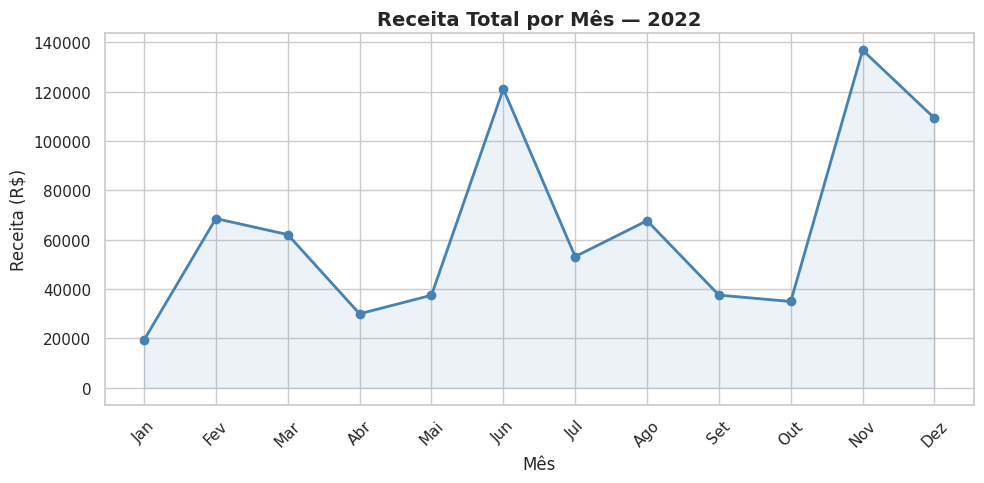

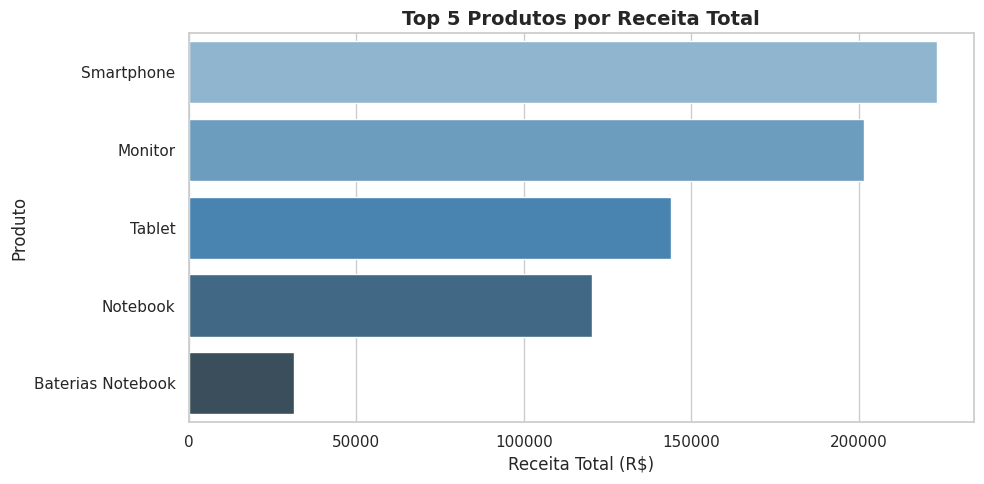

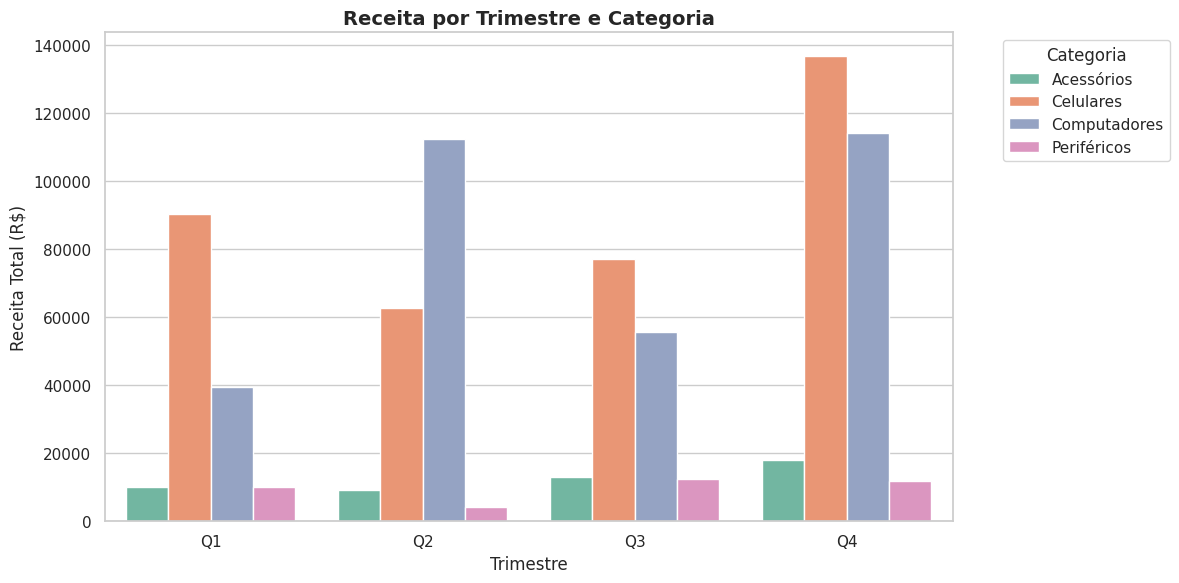


✅ 3 gráficos salvos em: outputs/graficos


In [ ]:
def gerar_visualizacoes(df, metricas, output_dir="outputs/graficos"):
    """
    Gera e exporta 3 gráficos informativos em PNG:
    1. Linha  — receita total por mês (tendência ao longo do tempo)
    2. Barras — top 5 produtos por receita (ranking)
    3. Barras agrupadas — receita por trimestre e categoria
    """
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")

    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun",
                   "Jul","Ago","Set","Out","Nov","Dez"]

    # --------------------------------------------------------
    # Gráfico 1: Linha — Receita Total por Mês
    # Ideal para mostrar tendência e sazonalidade ao longo do tempo
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    pm = metricas["por_mes"]
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2, color="steelblue")
    ax.fill_between(pm["mes"], pm["receita_total"], alpha=0.1, color="steelblue")
    ax.set_title("Receita Total por Mês — 2022", fontsize=14, fontweight="bold")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_abrev, rotation=45)
    plt.subplots_adjust(bottom=0.2)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=120)
    plt.show()
    plt.close()
    print("\n")

    # --------------------------------------------------------
    # Gráfico 2: Barras Horizontais — Top 5 Produtos por Receita
    # Barras horizontais facilitam a leitura de nomes longos
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=metricas["top_produtos"],
        y="produto",
        x="receita_total",
        hue="produto",
        legend=False,
        ax=ax,
        palette="Blues_d"
    )
    ax.set_title("Top 5 Produtos por Receita Total", fontsize=14, fontweight="bold")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Produto")
    plt.subplots_adjust(bottom=0.2)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=120)
    plt.show()
    plt.close()
    print("\n")

    # --------------------------------------------------------
    # Gráfico 3: Barras Agrupadas — Receita por Trimestre e Categoria
    # Mostra duas dimensões ao mesmo tempo: tempo e categoria
    # --------------------------------------------------------
    # Preparar os dados agrupando por trimestre e categoria
    df_trim_cat = (
        df.groupby(["trimestre", "categoria"])["receita_total"]
        .sum()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=df_trim_cat,
        x="trimestre",
        y="receita_total",
        hue="categoria",
        ax=ax,
        palette="Set2"
    )
    ax.set_title("Receita por Trimestre e Categoria", fontsize=14, fontweight="bold")
    ax.set_xlabel("Trimestre")
    ax.set_ylabel("Receita Total (R$)")
    ax.legend(title="Categoria", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.subplots_adjust(bottom=0.2)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_trimestre_categoria.png", dpi=120)
    plt.show()
    plt.close()

    print(f"\n✅ 3 gráficos salvos em: {output_dir}")


# Executar a geração dos gráficos
gerar_visualizacoes(df_analise, metricas)

RF10 - ORGANIZAR OS CÓDIGOS EM FUNÇÕES REUTILIZÁVEIS

In [ ]:
# DEMONSTRAÇÃO 1: Reutilização da função limpar_dados()
# A mesma função foi usada para gerar v1 e v2
# --------------------------------------------------------
print("=== DEMONSTRAÇÃO DE REUTILIZAÇÃO DE FUNÇÕES ===")
print("-" * 45)
print("  limpar_dados() foi reutilizada para gerar:")
print(f"    v1 (com outliers)    : {len(df_limpo_v1)} registros")
print(f"    v2 (sem outliers)    : {len(df_limpo_v2)} registros")
print("-" * 45)

# --------------------------------------------------------
# DEMONSTRAÇÃO 2: Função lambda
# Já usada na RF07, aqui demonstramos outro uso
# --------------------------------------------------------
print("\n=== DEMONSTRAÇÃO DE FUNÇÕES LAMBDA ===")
print("-" * 45)

# Lambda 1: já usada na segmentação de clientes (RF07)
print("  Lambda 1 — segmentação de clientes:")

p33 = clientes["total_gasto"].quantile(0.33)
p66 = clientes["total_gasto"].quantile(0.66)

exemplo_lambda1 = [40000, 25000, 4000]
print(f"    p33 = R$ {p33:,.2f} | p66 = R$ {p66:,.2f}")
for valor in exemplo_lambda1:
    segmento = (lambda g: "Ouro" if g > p66 else ("Prata" if g >= p33 else "Bronze"))(valor)
    print(f"    R$ {valor:,} → {segmento}")

# Lambda 2: formatação de receita em milhares
print("\n  Lambda 2 — receita em milhares (R$ k):")
formatar_em_k = lambda x: f"R$ {x/1000:.1f}k"
valores_exemplo = [2899.0, 15000.0, 43050.0]
for v in valores_exemplo:
    print(f"    {v} → {formatar_em_k(v)}")

print("-" * 45)

# --------------------------------------------------------
# DEMONSTRAÇÃO 3: Função de ordem superior (BÔNUS)
# Função que recebe outra função como parâmetro
# --------------------------------------------------------
print("\n=== DEMONSTRAÇÃO DE FUNÇÃO DE ORDEM SUPERIOR (BÔNUS) ===")
print("-" * 45)

def aplicar_transformacao(df, coluna, funcao):
    """
    Função de ordem superior: aplica qualquer função (incluindo lambdas)
    a uma coluna do DataFrame, criando uma nova coluna '_transformado'.
    Parâmetros:
        df     : DataFrame de entrada
        coluna : nome da coluna a transformar
        funcao : função ou lambda a aplicar — o 'callback'
    Retorna uma cópia do DataFrame com a nova coluna.
    """
    df = df.copy()
    df[f"{coluna}_transformado"] = df[coluna].apply(funcao)
    return df

# Uso 1: classificar vendas por ticket
df_demo1 = aplicar_transformacao(
    df_analise,
    "receita_total",
    lambda x: "Alto" if x > 5000 else "Normal"
)
print("  Uso 1 — classificação por ticket:")
print(df_demo1[["receita_total", "receita_total_transformado"]].head(4).to_string(index=False))

# Uso 2: receita em milhares
df_demo2 = aplicar_transformacao(
    df_analise,
    "receita_total",
    lambda x: round(x / 1000, 2)
)
print("\n  Uso 2 — receita em milhares (R$ k):")
print(df_demo2[["receita_total", "receita_total_transformado"]].head(4).to_string(index=False))

print("-" * 45)
print("\n✅ RF10 concluída — funções reutilizáveis demonstradas!")

=== DEMONSTRAÇÃO DE REUTILIZAÇÃO DE FUNÇÕES ===
---------------------------------------------
  limpar_dados() foi reutilizada para gerar:
    v1 (com outliers)    : 162 registros
    v2 (sem outliers)    : 150 registros
---------------------------------------------

=== DEMONSTRAÇÃO DE FUNÇÕES LAMBDA ===
---------------------------------------------
  Lambda 1 — segmentação de clientes:
    p33 = R$ 13,991.79 | p66 = R$ 33,495.76
    R$ 40,000 → Ouro
    R$ 25,000 → Prata
    R$ 4,000 → Bronze

  Lambda 2 — receita em milhares (R$ k):
    2899.0 → R$ 2.9k
    15000.0 → R$ 15.0k
    43050.0 → R$ 43.0k
---------------------------------------------

=== DEMONSTRAÇÃO DE FUNÇÃO DE ORDEM SUPERIOR (BÔNUS) ===
---------------------------------------------
  Uso 1 — classificação por ticket:
 receita_total receita_total_transformado
        2899.0                     Normal
         218.0                     Normal
         598.0                     Normal
        6995.0                       

RF11 - LER E ESCREVER ARQUIVOS (CSV E JSON)

In [ ]:
def exportar_resultados(metricas, clientes, stats):
    """
    Exporta os resultados da análise em dois formatos:
    - CSV : métricas mensais e segmentação de clientes
    - JSON: estatísticas gerais calculadas com NumPy
    """
    os.makedirs("outputs", exist_ok=True)

    # Salvar CSV 1 — métricas por mês
    metricas["por_mes"].to_csv(
        "outputs/metricas_por_mes.csv", index=False, encoding="utf-8-sig"
    )
    print("✅ CSV salvo: outputs/metricas_por_mes.csv")

    # Salvar CSV 2 — segmentação de clientes
    clientes.to_csv(
        "outputs/segmentacao_clientes.csv", index=False, encoding="utf-8-sig"
    )
    print("✅ CSV salvo: outputs/segmentacao_clientes.csv")

    # Salvar JSON — estatísticas gerais
    stats_serializaveis = {k: round(float(v), 2) for k, v in stats.items()}
    with open("outputs/estatisticas_gerais.json", "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
    print("✅ JSON salvo: outputs/estatisticas_gerais.json")

    # Ler o JSON de volta para confirmar
    with open("outputs/estatisticas_gerais.json", encoding="utf-8") as f:
        lido = json.load(f)
    print("\n📄 JSON lido de volta para confirmação:")
    print(json.dumps(lido, indent=2, ensure_ascii=False))


# Executar exportação
exportar_resultados(metricas, clientes, stats)

✅ CSV salvo: outputs/metricas_por_mes.csv
✅ CSV salvo: outputs/segmentacao_clientes.csv
✅ JSON salvo: outputs/estatisticas_gerais.json

📄 JSON lido de volta para confirmação:
{
  "media": 5183.68,
  "mediana": 1999.0,
  "desvio_padrao": 6149.2,
  "total": 777552.0,
  "minimo": 119.0,
  "maximo": 23192.0,
  "p25": 872.0,
  "p75": 8394.0,
  "acima_da_media": 51.0
}


RF12 - CONSOLIDAR A ÁNALISE E SALVAR O DATASET FINAL

In [ ]:
# Salvar o dataset final em data/final/
# Escolhemos df_limpo_v2 (outliers removidos) como base da análise final
os.makedirs("data/final", exist_ok=True)
df_analise.to_csv("data/final/vendas_final.csv", index=False)
print("✅ Dataset final salvo em: data/final/vendas_final.csv")

# Verificar se todos os arquivos esperados foram gerados
print("\n=== VERIFICAÇÃO DOS ARQUIVOS GERADOS ===")
print("-" * 45)

arquivos_esperados = [
    "data/raw/vendas.csv",
    "data/processed/v1_com_outliers/vendas_v1.csv",
    "data/processed/v2_outliers_tratado/vendas_v2.csv",
    "data/final/vendas_final.csv",
    "outputs/metricas_por_mes.csv",
    "outputs/segmentacao_clientes.csv",
    "outputs/estatisticas_gerais.json",
    "outputs/graficos/receita_por_mes.png",
    "outputs/graficos/top_produtos.png",
    "outputs/graficos/receita_trimestre_categoria.png"
]

todos_ok = True
for arquivo in arquivos_esperados:
    existe = os.path.exists(arquivo)
    status = "✅" if existe else "❌"
    print(f"  {status} {arquivo}")
    if not existe:
        todos_ok = False

print("-" * 45)
if todos_ok:
    print("\n✅ Todos os arquivos foram gerados com sucesso!")
else:
    print("\n⚠️ Alguns arquivos estão faltando — verifique as células anteriores.")

# Resumo final do pipeline
print("\n=== RESUMO FINAL DO PIPELINE ===")
print("-" * 45)
print(f"  Registros brutos gerados   : {len(df_total)}")
print(f"  Registros após limpeza(v1) : {len(df_limpo_v1)}")
print(f"  Registros após outliers(v2): {len(df_limpo_v2)}")
print(f"  Registros na análise final : {len(df_analise)}")
print(f"  Colunas no dataset final   : {len(df_analise.columns)}")
print(f"  Clientes segmentados       : {len(clientes)}")
print(f"  Receita total analisada    : R$ {df_analise['receita_total'].sum():,.2f}")
print("-" * 45)
print("\n✅ DataView — Análise concluída com sucesso!")

✅ Dataset final salvo em: data/final/vendas_final.csv

=== VERIFICAÇÃO DOS ARQUIVOS GERADOS ===
---------------------------------------------
  ✅ data/raw/vendas.csv
  ✅ data/processed/v1_com_outliers/vendas_v1.csv
  ✅ data/processed/v2_outliers_tratado/vendas_v2.csv
  ✅ data/final/vendas_final.csv
  ✅ outputs/metricas_por_mes.csv
  ✅ outputs/segmentacao_clientes.csv
  ✅ outputs/estatisticas_gerais.json
  ✅ outputs/graficos/receita_por_mes.png
  ✅ outputs/graficos/top_produtos.png
  ✅ outputs/graficos/receita_trimestre_categoria.png
---------------------------------------------

✅ Todos os arquivos foram gerados com sucesso!

=== RESUMO FINAL DO PIPELINE ===
---------------------------------------------
  Registros brutos gerados   : 180
  Registros após limpeza(v1) : 162
  Registros após outliers(v2): 150
  Registros na análise final : 150
  Colunas no dataset final   : 15
  Clientes segmentados       : 30
  Receita total analisada    : R$ 777,552.00
----------------------------------